In [50]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Annotated
from langchain_core.messages import BaseMessage, HumanMessage
from langchain_huggingface import ChatHuggingFace, HuggingFaceEndpoint
from langgraph.graph.message import add_messages
from dotenv import load_dotenv

from langgraph.prebuilt import ToolNode, tools_condition
from langchain_community.tools import DuckDuckGoSearchRun, DuckDuckGoSearchResults
from langchain_core.tools import tool
import requests
import random

In [51]:
load_dotenv()

True

In [52]:
llm = HuggingFaceEndpoint(
    repo_id="openai/gpt-oss-120b",
    task="text-generation"
)
model = ChatHuggingFace(llm=llm)

In [53]:
# tools

search_tool = DuckDuckGoSearchRun()

@tool
def get_stock_price(ticker: str) -> str:

    """Get the current stock price for a given ticker symbol."""
    
    # This is a mock implementation. In a real implementation, you would call an API to get the stock price.
    url = f"https://www.alphavantage.co/query?function=TIME_SERIES_DAILY&symbol={ticker}&apikey=4UW9NFMFLJWUL40X"
    response = requests.get(url)
    return response.json()

In [54]:
# Make tool list
tools = [search_tool, get_stock_price]

# Make llm tool-aware
llm_with_tools = model.bind_tools(tools)

In [55]:
# state
class ChatState(TypedDict):
    messages: Annotated[list[BaseMessage], add_messages]

In [56]:
# graph node
def chat_node(state: ChatState) -> str:
    """LLM node that can answer questions and call tools."""
    messages = state["messages"]
    response = llm_with_tools.invoke(messages)
    return {"messages":[response]}

tool_node = ToolNode(tools) # Node that can call tools

In [57]:
graph = StateGraph(ChatState)
graph.add_node("chat_node", chat_node)
graph.add_node("tools", tool_node)

In [58]:
graph.add_edge(START, "chat_node")
# The tool node should only be called if the LLM decides to call a tool, which is determined by the tools_condition function.
graph.add_conditional_edges("chat_node", tools_condition)

graph.add_edge("tools","chat_node")

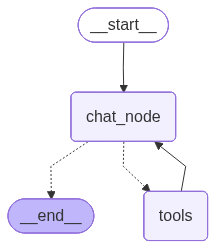

In [59]:
chatbot = graph.compile()

chatbot

In [60]:
# outputs

out = chatbot.invoke({"messages": [HumanMessage(content="What is the current stock price of AAPL?")]})
out

{'messages': [HumanMessage(content='What is the current stock price of AAPL?', additional_kwargs={}, response_metadata={}, id='920524c3-5fe1-4ad0-ba71-ba6cb453319c'),
  AIMessage(content='', additional_kwargs={'tool_calls': [{'function': {'arguments': '{"ticker":"AAPL"}', 'name': 'get_stock_price', 'description': None}, 'id': 'd51494ccc', 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 60, 'prompt_tokens': 185, 'total_tokens': 245}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_46358675aa6b1ba4d98d', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019e606d-5ac0-75d1-964e-44de947c57ef-0', tool_calls=[{'name': 'get_stock_price', 'args': {'ticker': 'AAPL'}, 'id': 'd51494ccc', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 185, 'output_tokens': 60, 'total_tokens': 245}),
  ToolMessage(content='{"Meta Data": {"1. Information": "Daily Prices (open, high, low, close) and Volumes", "2. Symbol": "AAPL",